# 03: Fixing the probabilities, with scikit-learn's calibration example

Notebook 02 found that the paper's logistic regression ranks customers as well
as Yeh & Lien (2009) report, but its probabilities are off in an S shape
(Figure 2.5). This notebook takes a published, runnable example on exactly that
problem. We run it as published, then adapt it to the Taiwan data to see
whether the probabilities can be fixed.

We use Probability Calibration curves, an example in the
scikit-learn documentation, version 1.9.1:
https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html
(source `examples/calibration/plot_calibration_curve.py`; © the scikit-learn
developers, BSD-3-Clause licence, which allows reuse with this notice).

This example compares logistic regression with Gaussian naive
Bayes, one of the six methods in Yeh & Lien (2009). It fixes probabilities
with `CalibratedClassifierCV` and scores them with the Brier score and log loss,
so it lets us both fix our logistic regression and test a second method from
the paper.

* Part A: the example's naive Bayes half, run unchanged on its synthetic data
* Part B: applying that method to the Taiwan data
* Part C: what the two resources tell us, across datasets and against the paper's

Run `01-Introduction.ipynb` first; Part B loads `data/processed/taiwan-clean.csv`.

## Part A: the example, as published

The code cells in this part are copied unchanged from the first half of the
example. Its second half repeats the method with a linear support vector
classifier, which isn't one of the paper's methods, so we left it out.

The paper uses a synthetic dataset of 100,000 rows and 20 columns. Only 2 columns
carry signal, 10 are mixtures of those 2, and 8 are noise. The example trains on
1,000 rows and tests on the other 99,000.

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=100_000, n_features=20, n_informative=2, n_redundant=10, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.99, random_state=42
)

The paper uses logistic regression as a baseline, which the example says is usually
well calibrated already, because it is fitted by minimising log loss. Then naive
Bayes, uncalibrated and with the two fixes `CalibratedClassifierCV` offers:

* sigmoid: fit a logistic curve from the
  model's score to the outcome;
* isotonic: fit any non-decreasing step function
  from the score to the outcome.

`cv=2` fits each fix by cross-validation inside the training data.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

lr = LogisticRegression(C=1.0)
gnb = GaussianNB()
gnb_isotonic = CalibratedClassifierCV(gnb, cv=2, method="isotonic")
gnb_sigmoid = CalibratedClassifierCV(gnb, cv=2, method="sigmoid")

clf_list = [
    (lr, "Logistic"),
    (gnb, "Naive Bayes"),
    (gnb_isotonic, "Naive Bayes + Isotonic"),
    (gnb_sigmoid, "Naive Bayes + Sigmoid"),
]

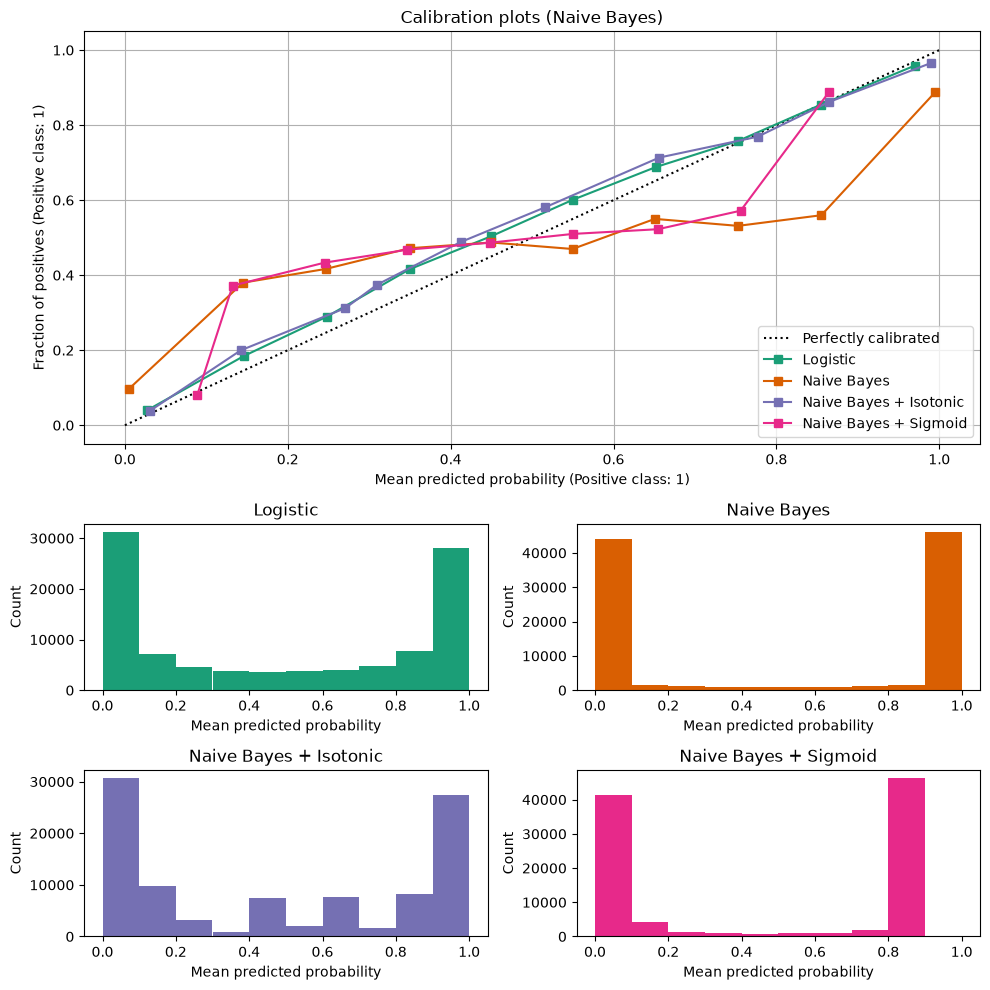

In [3]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        n_bins=10,
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots (Naive Bayes)")

# Add histogram
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=10,
        label=name,
        color=colors(i),
    )
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()

Figure 3.1 (the example's own plot, unchanged). Top: calibration curves,
each model's average prediction against the actual share of positives in 10
bins; the dotted diagonal is perfect. Bottom: how the predictions are spread.

The example explains that uncalibrated naive Bayes is over-confident. The 10
redundant columns break the critical assumption that columns are independent, so it
counts the same evidence several times and pushes probabilities towards 0 and 1.
That gives a "transposed sigmoid" curve. Isotonic calibration fixes it almost
completely, and sigmoid helps only a little.

Following this, the Brier score and log loss judge the probabilities, ROC AUC judges
the ranking, and precision, recall and F1 judge the yes/no predictions at
threshold 0.5.

In [4]:
from collections import defaultdict

import pandas as pd

from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

scores = defaultdict(list)
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)
    y_pred = clf.predict(X_test)
    scores["Classifier"].append(name)

    for metric in [brier_score_loss, log_loss, roc_auc_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_prob[:, 1]))

    for metric in [precision_score, recall_score, f1_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_pred))

    score_df = pd.DataFrame(scores).set_index("Classifier")
    score_df.round(decimals=3)

score_df

,Brier loss,Log loss,Roc auc,Precision,Recall,F1
Classifier,,,,,,
Logistic,0.098932,0.323200,0.937443,0.871965,0.851348,0.861533
Naive Bayes,0.117608,0.782755,0.940373,0.857400,0.875941,0.866571
Naive Bayes + Isotonic,0.098332,0.370738,0.938613,0.883065,0.836224,0.859007
Naive Bayes + Sigmoid,0.108880,0.368896,0.940201,0.861106,0.871277,0.866161


The example concludes that calibration improves the Brier score and log
loss but barely changes precision, recall and F1. ROC AUC "should not change at
all because calibration is a monotonic transformation". Sigmoid calibration can
fix a sigmoid shaped curve but not naive Bayes's transposed sigmoid; isotonic
can fix both, but may need more data.

Every number in the table matches the documentation
page to six decimal places.

## Part B: the same method on the Taiwan data

What we changed, and why:

1. The data: the cleaned Taiwan file, with the same three-way split as
   notebook 02 (same seeds), so the results line up.
2. The logistic regression is the paper's (no penalty, `C=np.inf`, scaled),
   not the example's `C=1.0`. Notebook 02 showed this makes no practical
   difference.
3. Calibrate on the calibration set, not by cross-validation. The example's
   `cv=2` refits the model inside its training data. We already set aside a
   calibration set for this job. So each model is fitted on train and frozen
   (`FrozenEstimator`, so `CalibratedClassifierCV` can't refit it), and only the
   correction is fitted, on the calibration set. Everything is scored on the
   test set.
4. Calibration curves use 10 equal-size groups (`strategy="quantile"`), as in
   Figure 2.5, not the example's 10 equal-width bins. Most customers have p
   between 0.1 and 0.3, so equal-width bins would leave most bins nearly empty.

In [5]:
from pathlib import Path
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.frozen import FrozenEstimator

ROOT = Path.cwd().parent            # notebooks run from report/
taiwan = pd.read_csv(ROOT / "data" / "processed" / "taiwan-clean.csv", index_col="ID")
Y = "default payment next month"
BLUE, ORANGE, GREY, GREEN = "#2a78d6", "#eb6834", "#8a8984", "#1a9e77"

# Same split as notebook 02: 60% train, 20% calibration, 20% test. (Replaces Part A's X and y.)
X = taiwan.drop(columns=Y)
y = taiwan[Y]
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=0)
X_train, X_cal, y_train, y_cal = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=0)

# 1. Fit the two base models on TRAIN.
logistic = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000))
naive_bayes = GaussianNB()
logistic.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

# 2. Freeze each one and fit only the correction on the CALIBRATION set.
models = {}
for base, name in [(logistic, "Logistic"), (naive_bayes, "Naive Bayes")]:
    models[name] = base
    for method in ["isotonic", "sigmoid"]:
        fixed = CalibratedClassifierCV(FrozenEstimator(base), method=method)
        models[f"{name} + {method.capitalize()}"] = fixed.fit(X_cal, y_cal)

# 3. Predicted probabilities on the TEST set, for every model.
p_test = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
list(models)

['Logistic',
 'Logistic + Isotonic',
 'Logistic + Sigmoid',
 'Naive Bayes',
 'Naive Bayes + Isotonic',
 'Naive Bayes + Sigmoid']

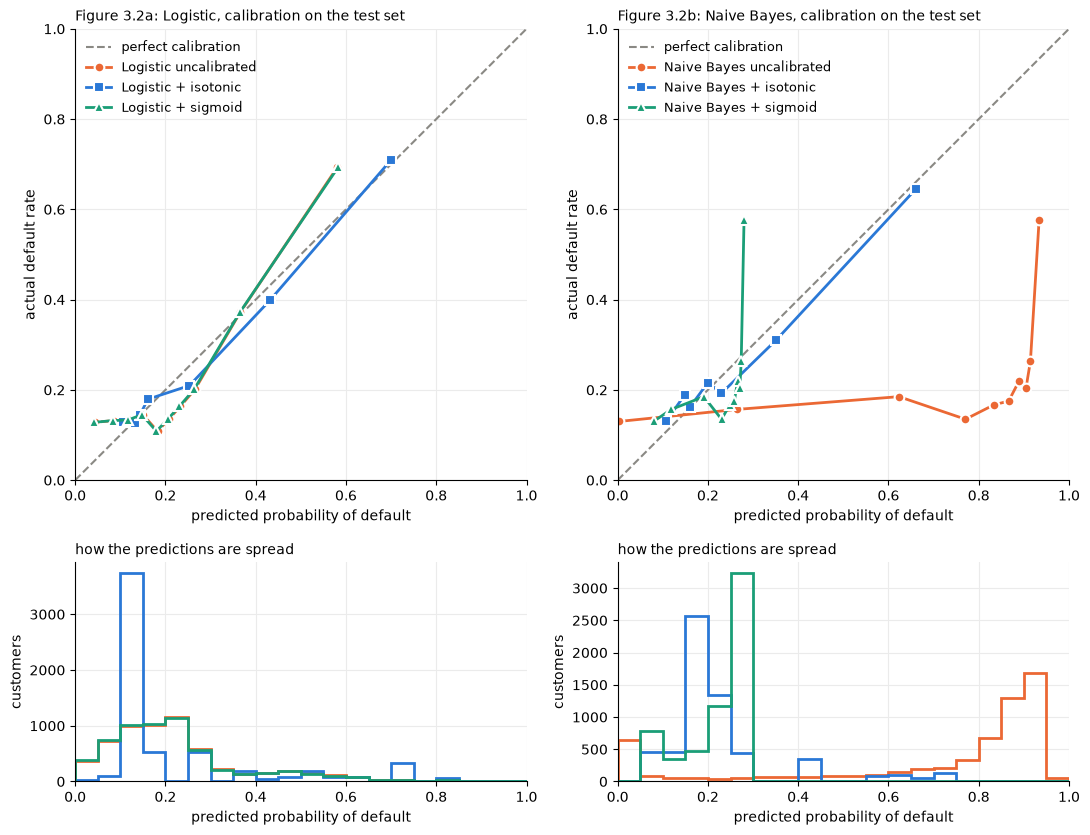

In [6]:
STYLE = {"":            (ORANGE, "o", "uncalibrated"),
         " + Isotonic": (BLUE,   "s", "+ isotonic"),
         " + Sigmoid":  (GREEN,  "^", "+ sigmoid")}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), gridspec_kw={"height_ratios": [2.2, 1]})
for col, base in enumerate(["Logistic", "Naive Bayes"]):
    ax, hx = axes[0, col], axes[1, col]
    ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.5, label="perfect calibration")
    for suffix, (colour, marker, label) in STYLE.items():
        p = p_test[base + suffix]
        frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, marker=marker, color=colour, linewidth=2, markersize=7,
                markeredgecolor="white", markeredgewidth=1.5, label=f"{base} {label}")
        hx.hist(p, bins=20, range=(0, 1), histtype="step", linewidth=2, color=colour)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_title(f"Figure 3.2{'ab'[col]}: {base}, calibration on the test set", loc="left", fontsize=10)
    ax.set_xlabel("predicted probability of default")
    ax.set_ylabel("actual default rate")
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    hx.set_xlim(0, 1)
    hx.set_xlabel("predicted probability of default")
    hx.set_ylabel("customers")
    hx.set_title("how the predictions are spread", loc="left", fontsize=10)
    for a in (ax, hx):
        a.spines[["top", "right"]].set_visible(False)
        a.grid(color="0.92"); a.set_axisbelow(True)
plt.tight_layout()
plt.show()

Figure 3.2. Top: each model's 10 groups, average prediction against actual
default rate, on the test set; on the dashed line is perfect. Bottom: how many
test customers get each predicted probability. Isotonic curves can show fewer
than 10 points, because isotonic maps customers onto a few dozen distinct
values, and groups that share a value merge.

Below is the example's metric table on the Taiwan test set, plus two columns of
ours: the share of customers flagged at 0.5, and the paper's error rate.

In [7]:
rows = {}
for name, m in models.items():
    p = p_test[name]
    flag = m.predict(X_test)                      # yes/no at threshold 0.5, as in the example
    rows[name] = {
        "Brier": brier_score_loss(y_test, p),
        "Log loss": log_loss(y_test, p),
        "Roc auc": roc_auc_score(y_test, p),
        # zero_division=0: a model that flags nobody has no precision; report 0 instead of an error.
        "Precision": precision_score(y_test, flag, zero_division=0),
        "Recall": recall_score(y_test, flag),
        "F1": f1_score(y_test, flag, zero_division=0),
        "share flagged": flag.mean(),
        "error rate": np.mean(flag != y_test),
    }
results = pd.DataFrame(rows).T
print(f"Brier score of predicting {y_train.mean():.1%} for everyone: "
      f"{brier_score_loss(y_test, np.full(len(y_test), y_train.mean())):.3f}")
results.round(3)

Brier score of predicting 22.1% for everyone: 0.172


,Brier,Log loss,Roc auc,Precision,Recall,F1,share flagged,error rate
Logistic,0.146,0.470,0.712,0.724,0.246,0.367,0.075,0.188
Logistic + Isotonic,0.141,0.474,0.715,0.678,0.361,0.471,0.118,0.179
Logistic + Sigmoid,0.146,0.471,0.712,0.726,0.247,0.369,0.075,0.187
Naive Bayes,0.462,1.515,0.652,0.240,0.864,0.375,0.796,0.636
Naive Bayes + Isotonic,0.156,0.490,0.650,0.646,0.192,0.296,0.066,0.202
Naive Bayes + Sigmoid,0.169,0.520,0.652,0.000,0.000,0.000,0.000,0.221


### Logistic regression: isotonic calibration fixes the S shape

* The probabilities are fixed. The 10 groups now lie near the diagonal
  (Figure 3.2a), and the Brier score improves from 0.146 to 0.141. Part C
  shows the paper's straight-line summary moving to slope 0.98, intercept 0.00,
  close to the ideal 1 and 0. Both the correction and the check use data the
  model never trained on.
* Log loss gets very slightly worse (0.470 → 0.474).
* Sigmoid calibration does almost nothing (Brier 0.146 both ways; the curves
  overlap). It fits a logistic curve to the model's score, and a logistic
  regression's output is already a logistic curve of a linear score. So it can
  only stretch the curve, not bend it into the S-shaped correction we need.
* ROC AUC moved slightly (0.712 → 0.715), although the example says it
  shouldn't. Isotonic is non-decreasing, not strictly increasing: it maps
  6,000 customers onto a few dozen values, creating ties, and AUC counts ties as
  half. The principle holds, but not to three decimal places.
* Calibration changes what 0.5 means. After isotonic, 11.8% of customers are
  above 0.5 (7.5% before), recall at 0.5 rises from 0.25 to 0.36, and the error
  rate falls to 0.179, just below the paper's 0.18. The ranking hasn't
  changed, only the scale of the scores. As in notebook 02, step 4: a threshold
  is a choice, not part of the model.

### Naive Bayes: very badly calibrated, and only partly fixable

Gaussian naive Bayes gives most customers a probability between 0.8 and
  0.95 (Figure 3.2b, bottom), although 22% default. It flags 80% of customers
  at 0.5, and its Brier score (0.462) is worse than predicting 22% for
  everyone (0.172). This is the over-confidence the example describes, with
  the same likely cause. Naive Bayes treats the columns as independent, but the
  six bill columns overlap heavily (Figure 2.1), so the same evidence is counted
  several times. The money columns are also very skewed, far from the bell
  curves Gaussian naive Bayes assumes.

## Part C: what the two resources tell us

The brief asks how approaches compare and carry across datasets, whether
generic resources apply, and how sharing code helps or limits. We answer with
one generic resource with code (scikit-learn) and one credit resource without
(Yeh & Lien, 2009).

First, the same method on both datasets, scored by Brier skill: the share of
the "predict the average for everyone" Brier score a model removes (1 perfect,
0 no better, below 0 worse). Raw Brier scores can't be compared across
datasets with different default rates.

In [8]:
# Part A's labels again (Part B replaced y), to get the synthetic data's yardstick.
_, y_syn = make_classification(
    n_samples=100_000, n_features=20, n_informative=2, n_redundant=10, random_state=42
)
_, y_syn_test = train_test_split(y_syn, test_size=0.99, random_state=42)

def skill(brier, y_ref):
    """Brier skill: the share of the 'predict the average for everyone' Brier score removed."""
    return 1 - brier / brier_score_loss(y_ref, np.full(len(y_ref), y_ref.mean()))

# The example builds its column names by deleting "score", leaving stray spaces ("Roc auc ").
example = score_df.rename(columns=str.strip)
names = ["Logistic", "Naive Bayes", "Naive Bayes + Isotonic", "Naive Bayes + Sigmoid"]
pd.DataFrame({
    "Brier skill, synthetic (A)": skill(example.loc[names, "Brier  loss"], y_syn_test),
    "Brier skill, Taiwan (B)":    skill(results.loc[names, "Brier"], y_test),
    "AUC, synthetic (A)":         example.loc[names, "Roc auc"],
    "AUC, Taiwan (B)":            results.loc[names, "Roc auc"],
}).round(3)

,"Brier skill, synthetic (A)","Brier skill, Taiwan (B)","AUC, synthetic (A)","AUC, Taiwan (B)"
Logistic,0.604,0.154,0.937,0.712
Naive Bayes,0.530,-1.683,0.940,0.652
Naive Bayes + Isotonic,0.607,0.092,0.939,0.650
Naive Bayes + Sigmoid,0.564,0.020,0.940,0.652


| | Synthetic (Part A) | Taiwan (Part B) | Carried over? |
|---|---|---|---|
| Naive Bayes over-confident | yes | yes | ✓ |
| Isotonic fixes it, sigmoid helps less | yes | yes | ✓ |
| Calibration leaves AUC unchanged | yes | yes | ✓ |
| Naive Bayes ranks as well as logistic | yes (AUC 0.94 vs 0.94) | no (0.65 vs 0.71) | ✗ |
| Best Brier skill | 0.60 | 0.15 | ✗ |

Results on an example don't predict results in our domain.

Next, the same models judged the paper's way: its Sorting Smoothing Method
line for probabilities (B = 1, A = 0 is perfect; notebook 02, step 5) and the
area ratio, 2 × AUC − 1, for ranking.

In [9]:
def ssm(y_true, p, n=50):
    """Yeh & Lien's Sorting Smoothing Method (as in notebook 02, step 5): sort by p, then a
    moving average of the outcomes over 2n+1 customers. Returns (predicted p, estimated real p)."""
    order = np.argsort(p, kind="stable")
    p_sorted, y_sorted = p[order], np.asarray(y_true)[order]
    window = 2 * n + 1
    real = np.convolve(y_sorted, np.ones(window) / window, mode="valid")
    return p_sorted[n:len(p_sorted) - n], real

def ssm_line(y_true, p, n=50):
    """Fit real = A + B * predicted, as in the paper's Table 2."""
    pred, real = ssm(y_true, p, n)
    B, A = np.polyfit(pred, real, 1)                  # polyfit returns the slope first
    return {"slope B": B, "intercept A": A, "R²": np.corrcoef(pred, real)[0, 1] ** 2}

paper = {
    "Logistic (Yeh & Lien)":    {"error rate": 0.18, "area ratio": 0.44, "slope B": 1.233, "intercept A": -0.0523, "R²": 0.794},
    "Naive Bayes (Yeh & Lien)": {"error rate": 0.21, "area ratio": 0.53, "slope B": 0.502, "intercept A": 0.0901,  "R²": 0.899},
}
ours = {f"{name} (ours)": {"error rate": results.loc[name, "error rate"],
                           "area ratio": 2 * results.loc[name, "Roc auc"] - 1,
                           **ssm_line(y_test, p_test[name])}
        for name in ["Logistic", "Logistic + Isotonic", "Naive Bayes", "Naive Bayes + Isotonic"]}
pd.DataFrame({**paper, **ours}).T.round(3)

,error rate,area ratio,slope B,intercept A,R²
Logistic (Yeh & Lien),0.180,0.440,1.233,-0.052,0.794
Naive Bayes (Yeh & Lien),0.210,0.530,0.502,0.090,0.899
Logistic (ours),0.188,0.425,1.119,-0.028,0.808
Logistic + Isotonic (ours),0.179,0.430,0.979,0.004,0.938
Naive Bayes (ours),0.636,0.303,0.170,0.098,0.167
Naive Bayes + Isotonic (ours),0.202,0.300,0.883,0.025,0.904


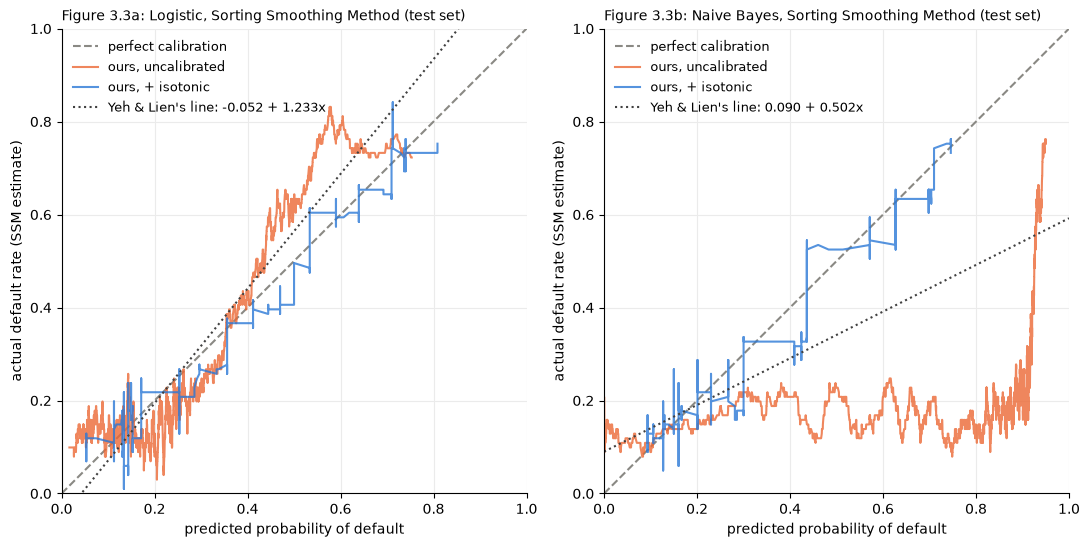

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, base in zip(axes, ["Logistic", "Naive Bayes"]):
    ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.5, label="perfect calibration")
    for suffix in ["", " + Isotonic"]:
        colour, _, label = STYLE[suffix]
        pred, real = ssm(y_test, p_test[base + suffix])
        ax.plot(pred, real, color=colour, linewidth=1.5, alpha=0.8, label=f"ours, {label}")
    # The paper reports only its straight line, so that is all we can draw for it.
    theirs = paper[f"{base} (Yeh & Lien)"]
    xs = np.array([0, 1])
    ax.plot(xs, theirs["intercept A"] + theirs["slope B"] * xs, color="0.25", linewidth=1.5,
            linestyle=":", label=f"Yeh & Lien's line: {theirs['intercept A']:.3f} + {theirs['slope B']:.3f}x")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_title(f"Figure 3.3{'ab'[base == 'Naive Bayes']}: {base}, Sorting Smoothing Method (test set)",
                 loc="left", fontsize=10)
    ax.set_xlabel("predicted probability of default")
    ax.set_ylabel("actual default rate (SSM estimate)")
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Figure 3.3. SSM curves on the test set, against the line the paper reports
for the same method. Isotonic curves jump vertically where many customers
share one p.

* For logistic regression, the two measures agree: isotonic moves the SSM
  line to slope 0.98, intercept 0.00, and lowers the Brier score.
* For naive Bayes, they disagree: its calibrated SSM line looks nearly as good
  (B = 0.88, R² = 0.90), but its Brier skill is lower than logistic
  regression's (0.09 against 0.15), because the SSM line ignores ranking. Use
  both kinds of measure.
* We couldn't reproduce the paper's naive Bayes. Theirs ranks above their
  logistic regression (area ratio 0.53 against 0.44), and ours ranks below
  (0.30 against 0.43). Our logistic regression matches the paper, so the
  difference is the method. The paper doesn't say which naive Bayes it used.

So the calibration method carries across datasets, but conclusions about which
model is best don't, from either the example or the paper. A generic resource
like scikit-learn's applies as a method, not as a set of settings: Part B had
to change its choices for credit data. Shared code made the difference: with
it we reproduced the example to six decimal places, and without it we couldn't
reproduce the paper's naive Bayes. Code is tied to library versions, though
(`cv="prefit"` fails on scikit-learn 1.9.1), so this repository pins them in
`requirements.txt`.

## Summary

| | Brier (test) | AUC | Verdict |
|---|---|---|---|
| Logistic, uncalibrated | 0.146 | 0.712 | ranks well, S-shaped probabilities (notebook 02) |
| Logistic + isotonic | 0.141 | 0.715 | probabilities fixed; ranking unchanged |
| Logistic + sigmoid | 0.146 | 0.712 | no effect: can't bend a logistic curve |
| Naive Bayes, uncalibrated | 0.462 | 0.652 | worse than predicting 22% for everyone |
| Naive Bayes + isotonic | 0.156 | 0.650 | probabilities rescued, ranking still poor |
| Predict 22% for everyone | 0.172 | 0.5 | yardstick |

The resource already gave us a ready-made, correct method for fixing
probabilities, and a warning (sigmoid can't fix every shape) that turned out to
apply to real data as well as to its synthetic example.

We ended up having to change the example calibrates by cross-validation and bins
by equal width. On credit data with a held-out calibration set and predictions
bunched between 0.1 and 0.3, a frozen model and equal-size groups were the
better fit.

We have seen that naive Bayes, which the paper ranks above
logistic regression, comes out well below it in scikit-learn's version. Without
the paper's code, this remains an area for further investigation.

## References

* scikit-learn developers (n.d.). Probability Calibration curves [code
  example], scikit-learn 1.9.1 documentation. Accessed 3 October 2026.
  https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html
* Yeh, I-C. & Lien, C-H. (2009). The comparisons of data mining techniques for
  the predictive accuracy of probability of default of credit card clients.
  Expert Systems with Applications 36(2), 2473–2480.
  https://doi.org/10.1016/j.eswa.2007.12.020

Full working: [`Oscar/08-calibration.ipynb`](../Oscar/08-calibration.ipynb).